In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math
import sys
from scipy.optimize import minimize
mpl.rcParams.update({'font.size': 20})
mpl.rcParams.update({'axes.linewidth': 2})

## Models for fitting

In [2]:
# Define the model: falling power law
def power_law_basic(x, A, alpha):
    return A * x**(-alpha)

def power_law(x, A, alpha, x0, k):
    return A * x**(-alpha) / (1 + np.exp(-(x - x0)*k))

# Define the model: falling shifted power law
def shifted_power_law_basic(x, N, a, b):
    return N * (b - 1) * a**(b - 1) * (x + a)**(-b)

def shifted_power_law(x, N, a, b, x0, k):
    return N * (b - 1) * a**(b - 1) * (x + a)**(-b) / (1 + np.exp(-(x - x0)*k))
   
# Define the model: falling exponential
def exponential_basic(x, A, alpha):
    return A * np.exp(-x * alpha)

def exponential(x, A, alpha, x0, k):
    return A * np.exp(-x * alpha) / (1 + np.exp(-(x - x0)*k))

# Negative log likelihood function to minimize
def negative_log_likelihood_power(params, x, counts):
    A, alpha, x0, k = params
    y = power_law(x, A, alpha, x0, k)
    nll = np.sum(y - counts * np.log(y))
    return nll

# Negative log likelihood function to minimize
def negative_log_likelihood_shifted_power(params, x, counts):
    N, a, b, x0, k = params
    y = shifted_power_law(x, N, a, b, x0, k)
    nll = np.sum(y - counts * np.log(y))
    return nll

# Negative log likelihood function to minimize
def negative_log_likelihood_exp(params, x, counts):
    A, alpha, x0, k = params
    y = exponential(x, A, alpha, x0, k)
    nll = np.sum(y - counts * np.log(y))
    return nll

# Negative log likelihood function to minimize
def negative_log_likelihood_power_basic(params, x, counts):
    A, alpha = params
    y = power_law_basic(x, A, alpha)
    nll = np.sum(y - counts * np.log(y))
    return nll

# Negative log likelihood function to minimize
def negative_log_likelihood_shifted_power_basic(params, x, counts):
    N, a, b = params
    y = shifted_power_law_basic(x, N, a, b)
    nll = np.sum(y - counts * np.log(y))
    return nll

# Negative log likelihood function to minimize
def negative_log_likelihood_exp_basic(params, x, counts):
    A, alpha = params
    y = exponential_basic(x, A, alpha)
    nll = np.sum(y - counts * np.log(y))
    return nll


## Getting fit parameters for exponential and power laws

### Loading data

In [3]:
# Mass [kg] = Volume [cm3] x Density [g/cm3] x Unit conversion [kg/g]
mass_kg = (1 * 1 * 0.1) * 2.329 * 1e-3
time_days = 12 / 24 * 0.612 # 12 hours of data, 0.612 passage fraciton
time_sec = time_days * 86400
print(f'{mass_kg * 1000:.4f} grams of Si')


0.2329 grams of Si


151080 events
Check unit conversion: integral = 128136.0 events, and real data = 151080 events
128737 events
Check unit conversion: integral = 99424.0 events, and real data = 128737 events
165935 events
Check unit conversion: integral = 125219.0 events, and real data = 165935 events


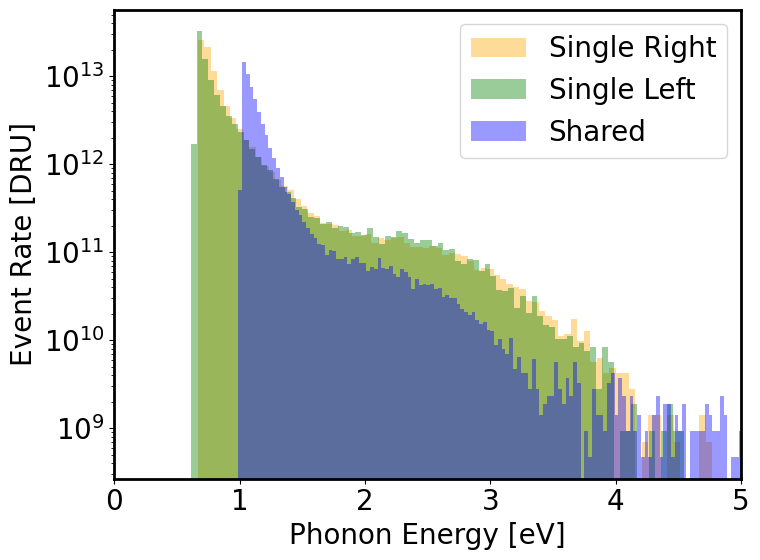

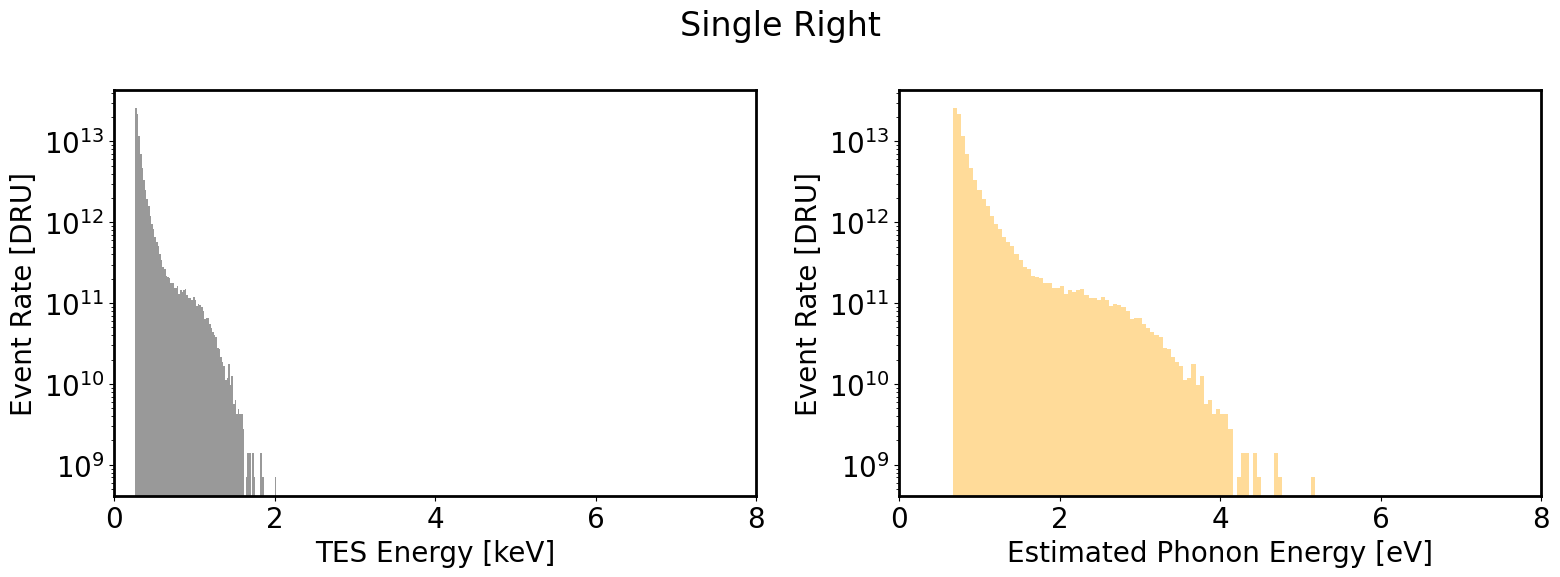

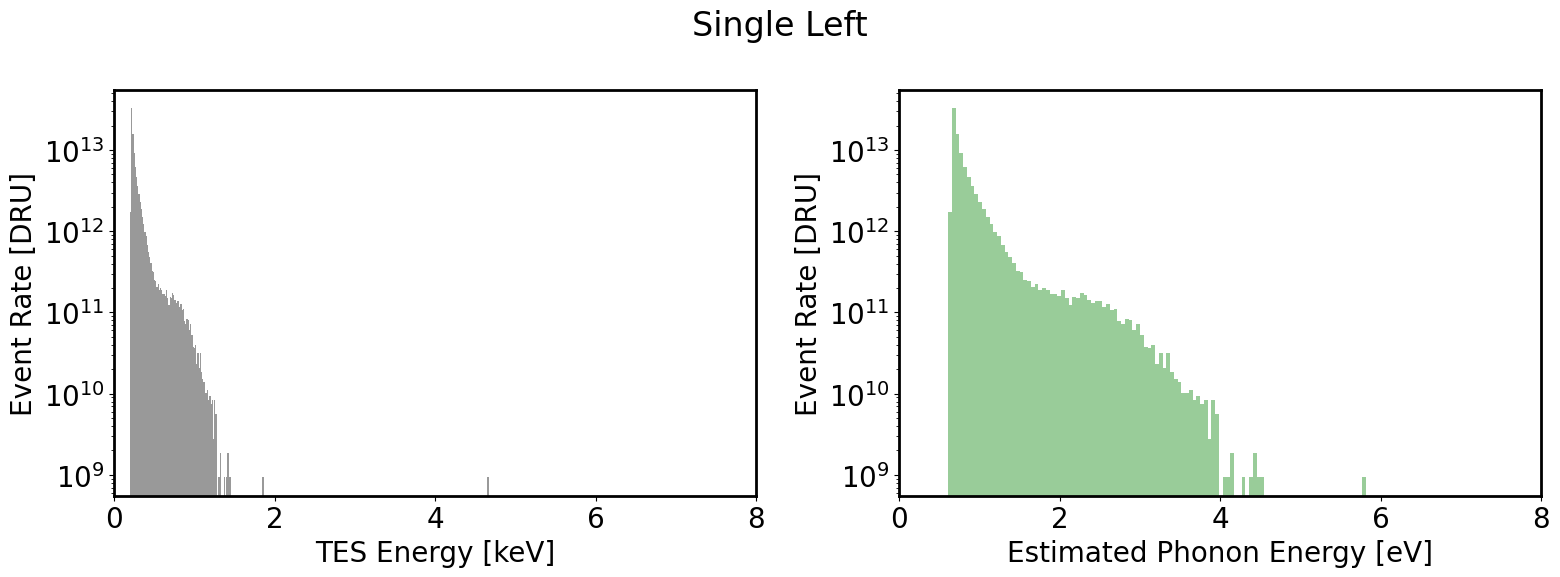

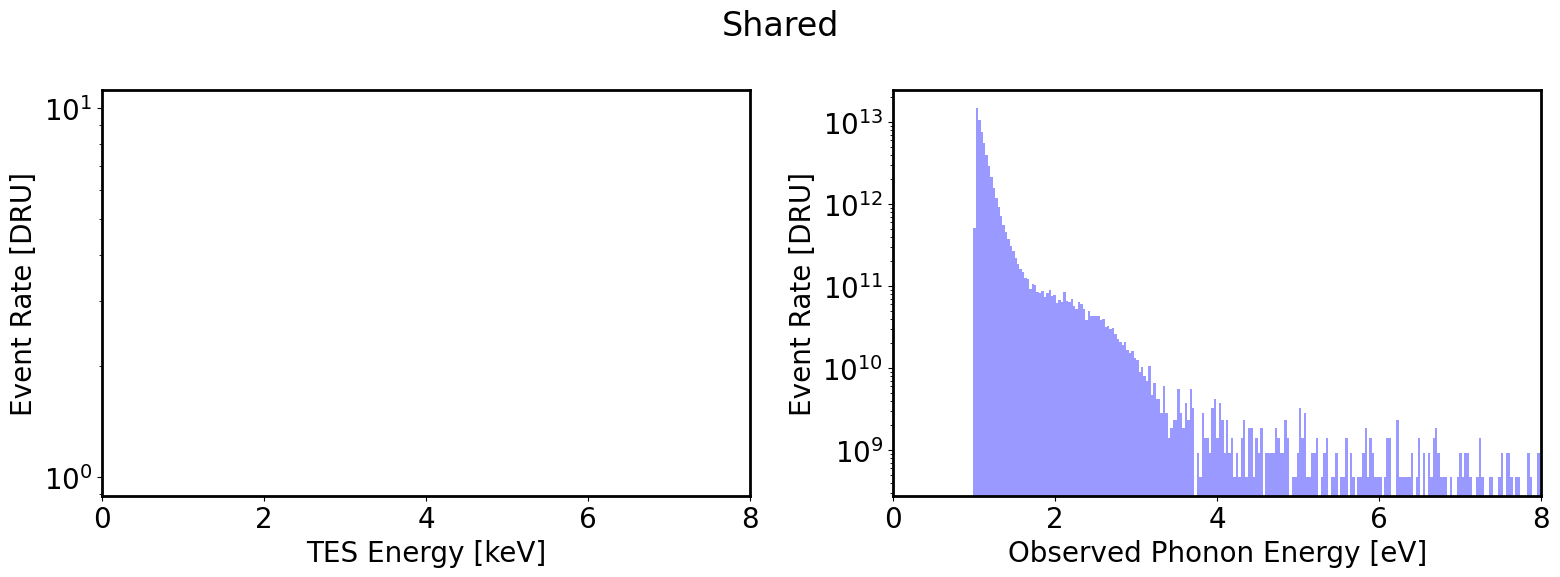

In [4]:
fig_all, ax_all = plt.subplots(1, 1, figsize=(8, 6))

for i, (fn, label, color) in enumerate(zip(
    ['spectra/r57_1226_1mm_single_right.npy', 'spectra/r57_1226_1mm_single_left.npy', 'spectra/r57_1226_1mm_shared.npy'],
    ['Single Right', 'Single Left', 'Shared'],
    ['orange', 'green', 'blue']
    )):
    
    energies_eV = np.load(fn)
    energies_keV = energies_eV / 1000
    print(f'{len(energies_eV)} events')

    if label == 'Single Right':
        pce = 0.39
        bins_eV_full = np.arange(0, max(energies_eV) + 4, 0.02)
    elif label == 'Single Left':
        pce = 0.32
        bins_eV_full = np.arange(0, max(energies_eV) + 4, 0.015)
    else:
        pce = 1.
        bins_eV_full = np.arange(0, max(energies_eV) + 4, 0.03)
        
    bins_keV_full = bins_eV_full / 1000

    event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

    ####### Plotting #######

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    ax[1].hist(energies_keV * 1e3 / pce, bins_keV_full * 1e3 / pce, weights=event_weights_DRU, alpha=0.4, color=color)
    
    if label == 'Shared':
        ax[1].set_xlabel('Observed Phonon Energy [eV]')
    else:
        ax[0].hist(energies_keV * 1e3, bins_keV_full * 1e3, weights=event_weights_DRU, alpha=0.4, color='k')
        ax[1].set_xlabel('Estimated Phonon Energy [eV]')
       
    for j in range(2):
        ax[j].set_xlim([0, 8])
        ax[j].set_yscale('log')
        ax[j].set_ylabel('Event Rate [DRU]')

    ax[0].set_xlabel('TES Energy [keV]')
    
    fig.suptitle(label)
    fig.tight_layout()
    fig.show()

    ax_all.hist(energies_keV * 1e3 / pce, bins_keV_full * 1e3 / pce, weights=event_weights_DRU, alpha=0.4, label=label, color=color)

    ####### Check unit conversion #######

    bin_counts, bin_edges = np.histogram(energies_keV, bins_keV_full, weights=event_weights_DRU)
    norm = sum(bin_counts * np.diff(bin_edges) * mass_kg * time_days)
    print(f'Check unit conversion: integral = {norm:.1f} events, and real data = {len(energies_eV)} events')

ax_all.set_yscale('log')
ax_all.set_xlabel('Phonon Energy [eV]')
ax_all.set_ylabel('Event Rate [DRU]')
ax_all.set_xlim([0, 5])
ax_all.legend(loc='upper right')
fig_all.tight_layout()
fig_all.show()

## Low-Energy Shared Fit

In [5]:
energies_eV = np.load('spectra/r57_1226_1mm_shared.npy')
energies_keV = energies_eV / 1000

bins_eV_full = np.arange(0.5, 5, 0.02)
bins_keV_full = bins_eV_full / 1000

# Do the fit in eV, then convert to keV (it converges better this way)
fit_low, fit_high = 0.9, 1.7
bins_eV_fit = bins_eV_full[(bins_eV_full > fit_low) * (bins_eV_full < fit_high)]

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

In [6]:
dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_fit, weights=event_weights_DRU)
counts_arr, _ = np.histogram(energies_eV, bins_eV_fit)

E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
E_keV_arr = E_eV_arr / 1000

Power law parameters (raw): A = 3.031e+00, alpha = -11.4736
Threshold = 1.016e+00 eV, inverse width = 5.00000e+02 1/eV
Power law parameters [in proper units]: A = 8.072e-22 DRU, alpha = -11.4736
Threshold = 1.016e-03 keV, width = 2.00000e-06 keV

Exponential parameters [raw]: A = 3.526e+01, inverse E0 = 9.4829e+00 1/eV
Threshold = 1.016e+00 eV, inverse width = 5.00006e+02 1/eV
Exponential parameters [in proper units]: A = 2.474e+17 DRU, E0 = 1.0545e-04 keV
Threshold = 1.016e-03 keV, width = 2.0000e-06 keV

Shifted Power law parameters [raw]: N = 1.475e+01, a = 1.2266 eV, b = 23.0620
Threshold = 1.016e+00 eV, inverse width = 5.00001e+02 1/eV
Shifted Power law parameters [in keV]: N = 1.035e+15 DRU, a = 0.0012 keV, b = 23.0620
Threshold = 1.016e-03 eV, width = 2.00000e-06 eV



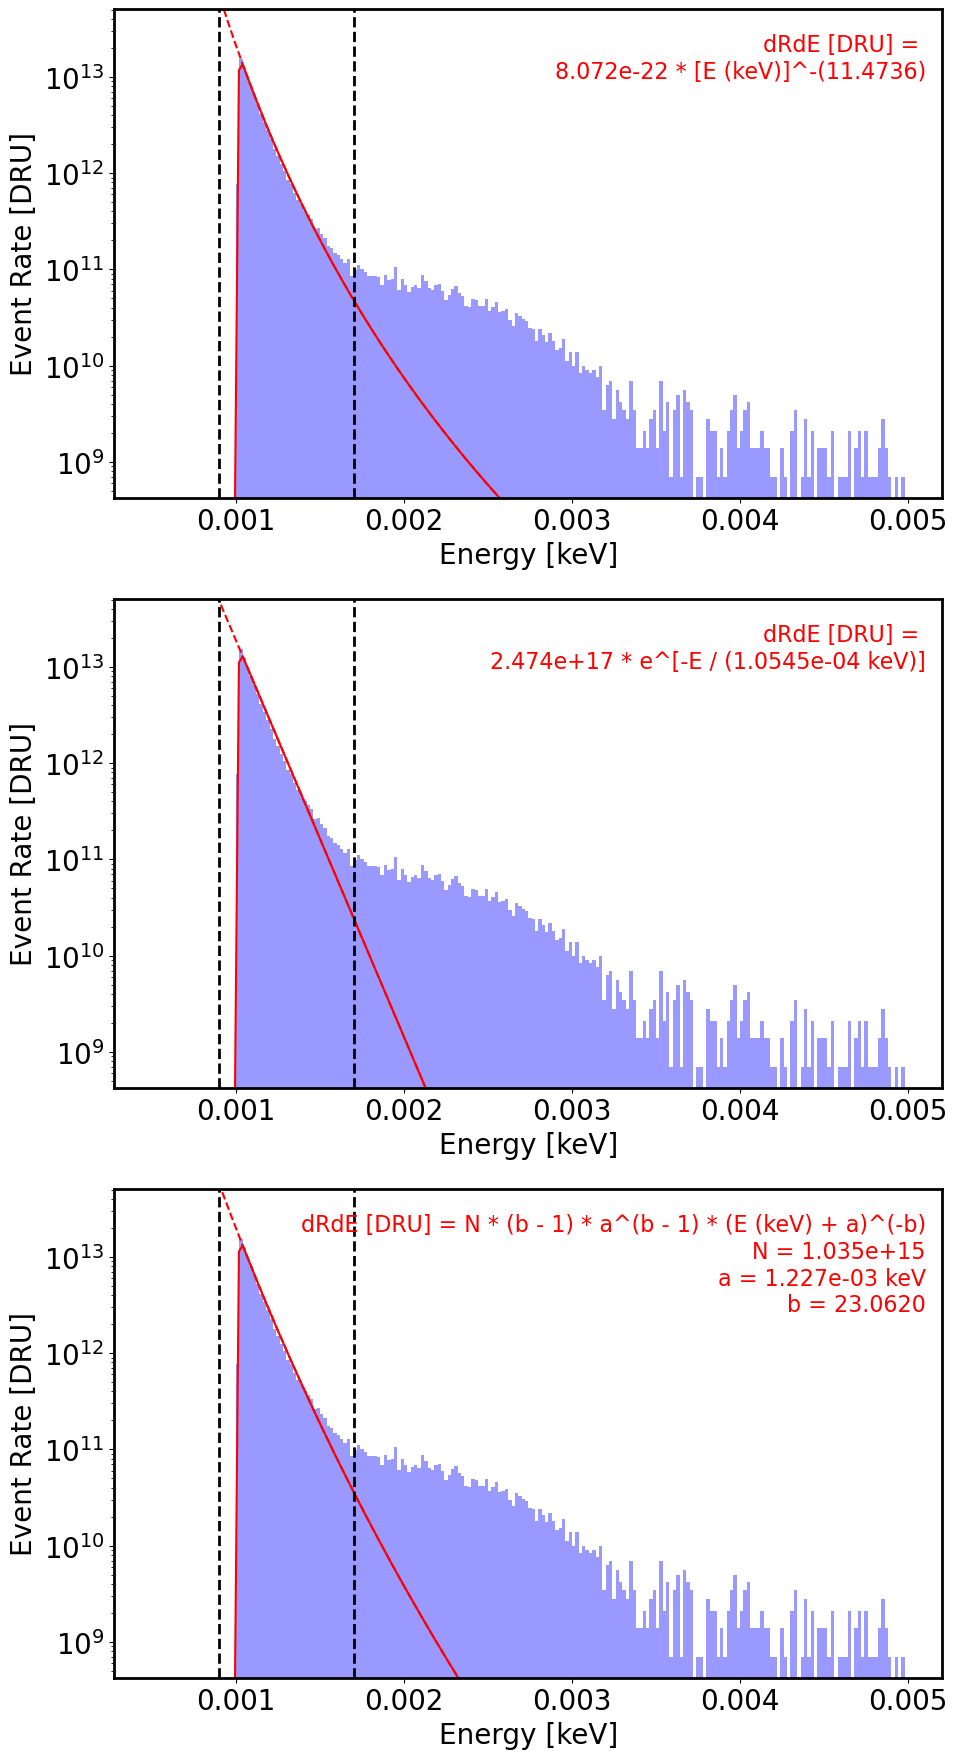

In [7]:
### Minimize the negative log likelihood for a power-law background
fit_scale = 1e4 # Divide the rate first to help the fit converge

# Do the fit in eV space to make it easier to fit, then convert to keV
result = minimize(negative_log_likelihood_power,
                  [1, 10, 1, 500],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None), (0.5, 1.5), (1e-10, None)])
A_fit_power, alpha_fit_power, Eth_power, inv_width_power = result.x
print(f"Power law parameters (raw): A = {A_fit_power:.3e}, alpha = -{alpha_fit_power:.4f}")
print(f'Threshold = {Eth_power:.3e} eV, inverse width = {inv_width_power:.5e} 1/eV')

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
A_fit_power *= fit_scale * 1000**(-1 * alpha_fit_power) * event_weights_DRU[0] 
Eth_power *= (1/1000)
inv_width_power *= 1000
print(f"Power law parameters [in proper units]: A = {A_fit_power:.3e} DRU, alpha = -{alpha_fit_power:.4f}")
print(f'Threshold = {Eth_power:.3e} keV, width = {1 / inv_width_power:.5e} keV')
print('')



### Minimize the negative log likelihood for a exponential background
fit_scale = 1e7 # Divide the rate first to help the fit converge

# Do the fit in eV space to make it easier to fit, then convert to keV
result = minimize(negative_log_likelihood_exp,
                  [1, 1, 1, 500],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None), (0.5, 1.5), (1e-10, None)])
A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp = result.x
print(f"Exponential parameters [raw]: A = {A_fit_exp:.3e}, inverse E0 = {inv_E0_exp:.4e} 1/eV")
print(f'Threshold = {Eth_exp:.3e} eV, inverse width = {inv_width_exp:.5e} 1/eV')

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
A_fit_exp *= fit_scale * event_weights_DRU[0]
inv_E0_exp *= 1000
Eth_exp *= (1/1000)
inv_width_exp *= 1000
print(f"Exponential parameters [in proper units]: A = {A_fit_exp:.3e} DRU, E0 = {1 / inv_E0_exp:.4e} keV")
print(f'Threshold = {Eth_exp:.3e} keV, width = {1 / inv_width_exp:.4e} keV')
print('')



### Minimize the negative log likelihood for a shifted power-law background
fit_scale = 1e8
result = minimize(negative_log_likelihood_shifted_power,
                  [1, 0.5, 11., 1., 500.],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None), (1, None), (0.5, 1.5), (1e-10, None)])
N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted = result.x
print(f"Shifted Power law parameters [raw]: N = {N_fit_shifted:.3e}, a = {a_fit_shifted:.4f} eV, b = {b_fit_shifted:.4f}")
print(f'Threshold = {Eth_shifted:.3e} eV, inverse width = {inv_width_shifted:.5e} 1/eV')

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
N_fit_shifted *= fit_scale * (1/1000) * event_weights_DRU[0]
a_fit_shifted *= (1/1000)
Eth_shifted *= (1/1000)
inv_width_shifted *= 1000
print(f"Shifted Power law parameters [in keV]: N = {N_fit_shifted:.3e} DRU, a = {a_fit_shifted:.4f} keV, b = {b_fit_shifted:.4f}")
print(f'Threshold = {Eth_shifted:.3e} eV, width = {1 / inv_width_shifted:.5e} eV')
print('')



####### Plotting #######

fig, ax = plt.subplots(3, 1, figsize=(10, 18))

for i in range(3):
    ax[i].hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='b')
    ax[i].set_yscale('log')
    ymin, ymax = ax[i].get_ylim()

    keV_arr_fit = np.linspace(min(bins_keV_full), max(bins_keV_full), 200)
    
    if i == 0:
        ax[i].plot(keV_arr_fit, power_law(keV_arr_fit, A_fit_power, alpha_fit_power, Eth_power, inv_width_power), 'r-')
        ax[i].plot(keV_arr_fit, power_law_basic(keV_arr_fit, A_fit_power, alpha_fit_power), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_power:.3e} * [E (keV)]^-({alpha_fit_power:.4f})', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 1:
        ax[i].plot(keV_arr_fit, exponential(keV_arr_fit, A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp), 'r-')
        ax[i].plot(keV_arr_fit, exponential_basic(keV_arr_fit, A_fit_exp, inv_E0_exp), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_exp:.3e} * e^[-E / ({1/inv_E0_exp:.4e} keV)]', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 2:
        #ax[i].set_xscale('log')
        #ax[i].plot(keV_arr_fit, shifted_power_law(keV_arr_fit, 1e16, 3e-4, 12, 1e-3, 1e6), 'r-')
        ax[i].plot(keV_arr_fit, shifted_power_law(keV_arr_fit, N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted), 'r-')
        ax[i].plot(keV_arr_fit, shifted_power_law_basic(keV_arr_fit, N_fit_shifted, a_fit_shifted, b_fit_shifted), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = N * (b - 1) * a^(b - 1) * (E (keV) + a)^(-b)\nN = {N_fit_shifted:.3e}\na = {a_fit_shifted:.3e} keV\nb = {b_fit_shifted:.4f}',
                   ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)

    #ax[i].text(3, 5e11, f'Fit Region', ha='right', va='top', fontsize=24, color='k')

    ax[i].set_xlabel('Energy [keV]')
    ax[i].set_ylabel('Event Rate [DRU]')

    ax[i].plot([fit_low/1e3, fit_low/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].plot([fit_high/1e3, fit_high/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].set_ylim([ymin, ymax*2])

fig.tight_layout()
fig.show()


## Medium-Energy Shared Fit

In [8]:
energies_eV = np.load('spectra/r57_1226_1mm_shared.npy')
energies_keV = energies_eV / 1000

bins_eV_full = np.arange(0.5, 20, 0.3)
bins_keV_full = bins_eV_full / 1000

# Do the fit in eV, then convert to keV (it converges better this way)
fit_low, fit_high = 4.5, 15
bins_eV_fit = bins_eV_full[(bins_eV_full > fit_low) * (bins_eV_full < fit_high)]

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

In [9]:
dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_fit, weights=event_weights_DRU)
counts_arr, _ = np.histogram(energies_eV, bins_eV_fit)

E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
E_keV_arr = E_eV_arr / 1000

Power law parameters (raw): A = 3.721e-01, alpha = -3.1139
Power law parameters [in proper units]: A = 7.922e+01 DRU, alpha = -3.1139

Exponential parameters [raw]: A = 1.567e+00, inverse E0 = 3.9485e-01 1/eV
Exponential parameters [in proper units]: A = 7.329e+09 DRU, E0 = 2.5326e-03 keV

Shifted Power law parameters [raw]: N = 7.241e-01, a = 0.0168 eV, b = 3.4709
Shifted Power law parameters [in keV]: N = 3.387e+12 DRU, a = 0.0000 keV, b = 3.4709



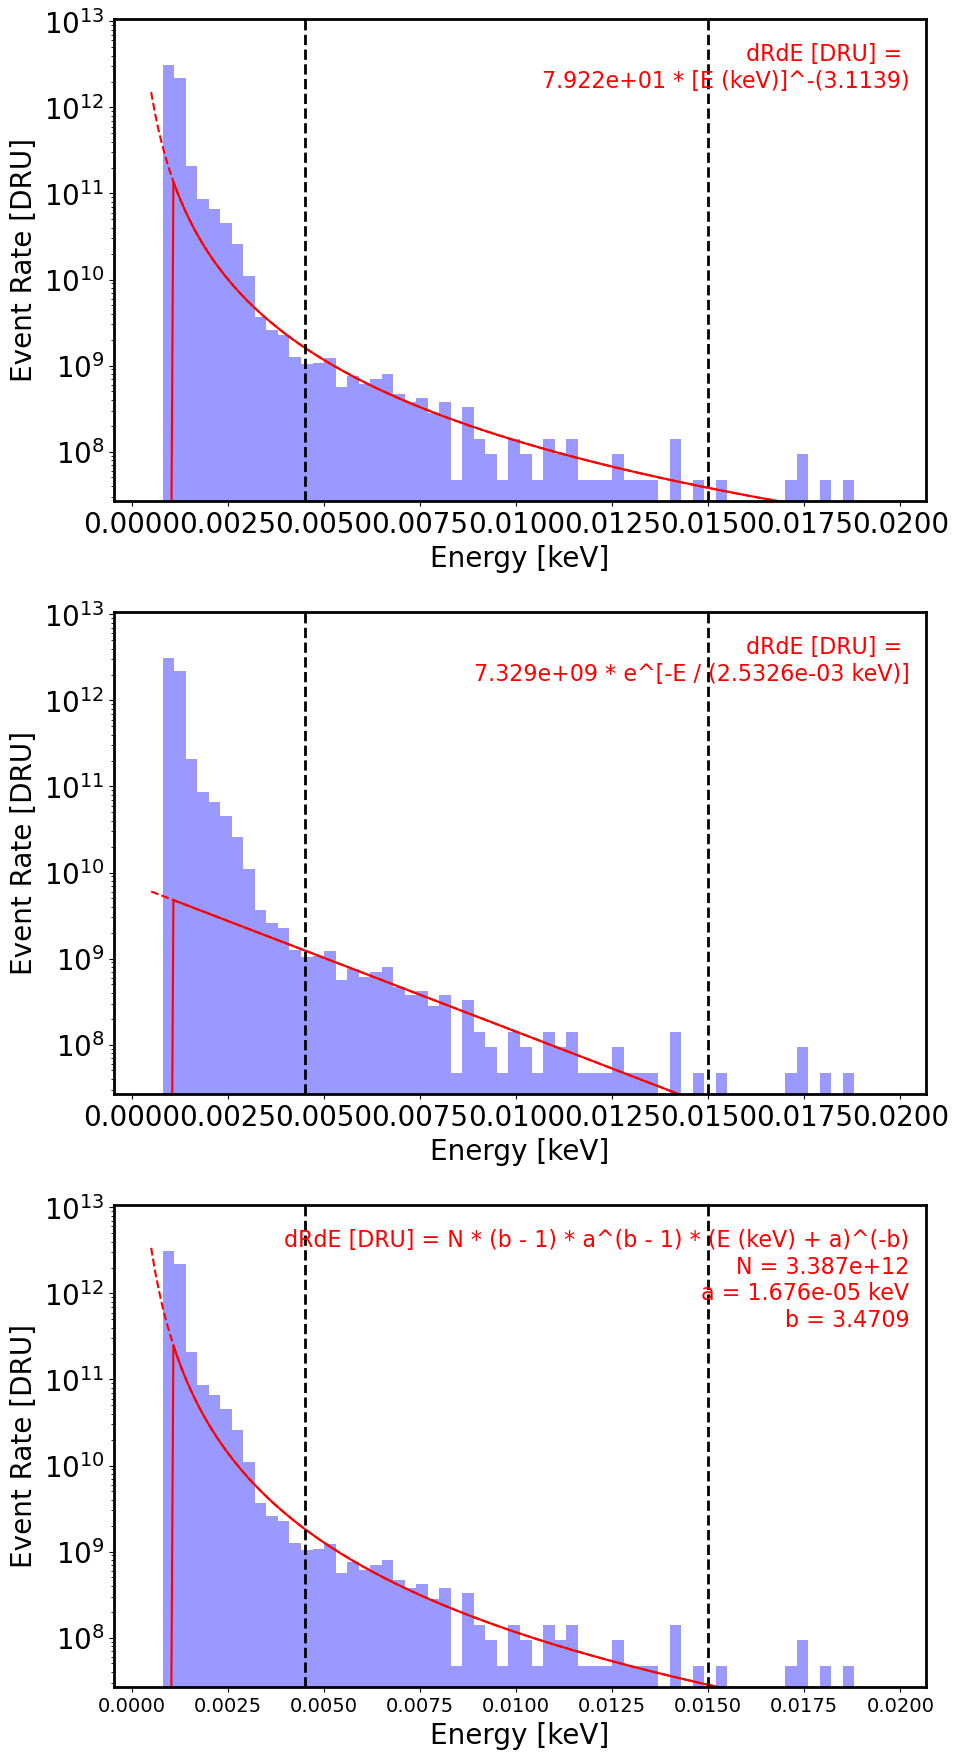

In [10]:
### Minimize the negative log likelihood for a power-law background
fit_scale = 1e4 # Divide the rate first to help the fit converge

# Do the fit in eV space to make it easier to fit, then convert to keV
result = minimize(negative_log_likelihood_power_basic,
                  [1, 10],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None)])
A_fit_power_me, alpha_fit_power_me = result.x
print(f"Power law parameters (raw): A = {A_fit_power_me:.3e}, alpha = -{alpha_fit_power_me:.4f}")

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
A_fit_power_me *= fit_scale * 1000**(-1 * alpha_fit_power_me) * event_weights_DRU[0] 
print(f"Power law parameters [in proper units]: A = {A_fit_power_me:.3e} DRU, alpha = -{alpha_fit_power_me:.4f}")
print('')



### Minimize the negative log likelihood for a exponential background
fit_scale = 1e2 # Divide the rate first to help the fit converge

# Do the fit in eV space to make it easier to fit, then convert to keV
result = minimize(negative_log_likelihood_exp_basic,
                  [1, 0.3],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None)])
A_fit_exp_me, inv_E0_exp_me = result.x
print(f"Exponential parameters [raw]: A = {A_fit_exp_me:.3e}, inverse E0 = {inv_E0_exp_me:.4e} 1/eV")

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
A_fit_exp_me *= fit_scale * event_weights_DRU[0]
inv_E0_exp_me *= 1000
print(f"Exponential parameters [in proper units]: A = {A_fit_exp_me:.3e} DRU, E0 = {1 / inv_E0_exp_me:.4e} keV")
print('')



### Minimize the negative log likelihood for a shifted power-law background
fit_scale = 1e8
result = minimize(negative_log_likelihood_shifted_power_basic,
                  [1, 1, 3.],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None), (1, None)])
N_fit_shifted_me, a_fit_shifted_me, b_fit_shifted_me = result.x
print(f"Shifted Power law parameters [raw]: N = {N_fit_shifted_me:.3e}, a = {a_fit_shifted_me:.4f} eV, b = {b_fit_shifted_me:.4f}")

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
N_fit_shifted_me *= fit_scale * (1/1000) * event_weights_DRU[0]
a_fit_shifted_me *= (1/1000)
print(f"Shifted Power law parameters [in keV]: N = {N_fit_shifted_me:.3e} DRU, a = {a_fit_shifted_me:.4f} keV, b = {b_fit_shifted_me:.4f}")
print('')



####### Plotting #######

fig, ax = plt.subplots(3, 1, figsize=(10, 18))

for i in range(3):
    ax[i].hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='b')
    ax[i].set_yscale('log')
    ymin, ymax = ax[i].get_ylim()

    keV_arr_fit = np.linspace(min(bins_keV_full), max(bins_keV_full), 200)
    
    if i == 0:
        ax[i].plot(keV_arr_fit, power_law(keV_arr_fit, A_fit_power_me, alpha_fit_power_me, Eth_power, inv_width_power), 'r-')
        ax[i].plot(keV_arr_fit, power_law_basic(keV_arr_fit, A_fit_power_me, alpha_fit_power_me), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_power_me:.3e} * [E (keV)]^-({alpha_fit_power_me:.4f})', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 1:
        ax[i].plot(keV_arr_fit, exponential(keV_arr_fit, A_fit_exp_me, inv_E0_exp_me, Eth_exp, inv_width_exp), 'r-')
        ax[i].plot(keV_arr_fit, exponential_basic(keV_arr_fit, A_fit_exp_me, inv_E0_exp_me), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_exp_me:.3e} * e^[-E / ({1/inv_E0_exp_me:.4e} keV)]', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 2:
        #ax[i].set_xscale('log')
        #ax[i].plot(keV_arr_fit, shifted_power_law(keV_arr_fit, 1e16, 3e-4, 12, 1e-3, 1e6), 'r-')
        ax[i].plot(keV_arr_fit, shifted_power_law(keV_arr_fit, N_fit_shifted_me, a_fit_shifted_me, b_fit_shifted_me, Eth_shifted, inv_width_shifted), 'r-')
        ax[i].plot(keV_arr_fit, shifted_power_law_basic(keV_arr_fit, N_fit_shifted_me, a_fit_shifted_me, b_fit_shifted_me), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = N * (b - 1) * a^(b - 1) * (E (keV) + a)^(-b)\nN = {N_fit_shifted_me:.3e}\na = {a_fit_shifted_me:.3e} keV\nb = {b_fit_shifted_me:.4f}',
                   ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)

    #ax[i].text(3, 5e11, f'Fit Region', ha='right', va='top', fontsize=24, color='k')

    ax[i].set_xlabel('Energy [keV]')
    ax[i].set_ylabel('Event Rate [DRU]')

    ax[i].plot([fit_low/1e3, fit_low/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].plot([fit_high/1e3, fit_high/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].set_ylim([ymin, ymax*2])
    
ax[2].tick_params(axis='x', which='major', labelsize=14)


fig.tight_layout()
fig.show()


## Residual Peak

In [11]:
energies_eV = np.load('spectra/r57_1226_1mm_shared.npy')
energies_keV = energies_eV / 1000

bins_eV_full = np.arange(0., 20, 0.1)
bins_keV_full = bins_eV_full / 1000

# Do the fit in eV, then convert to keV (it converges better this way)
fit_low, fit_high = 4.5, 15
bins_eV_fit = bins_eV_full[(bins_eV_full > fit_low) * (bins_eV_full < fit_high)]

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

In [12]:
dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_fit, weights=event_weights_DRU)
counts_arr, _ = np.histogram(energies_eV, bins_eV_fit)

E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
E_keV_arr = E_eV_arr / 1000

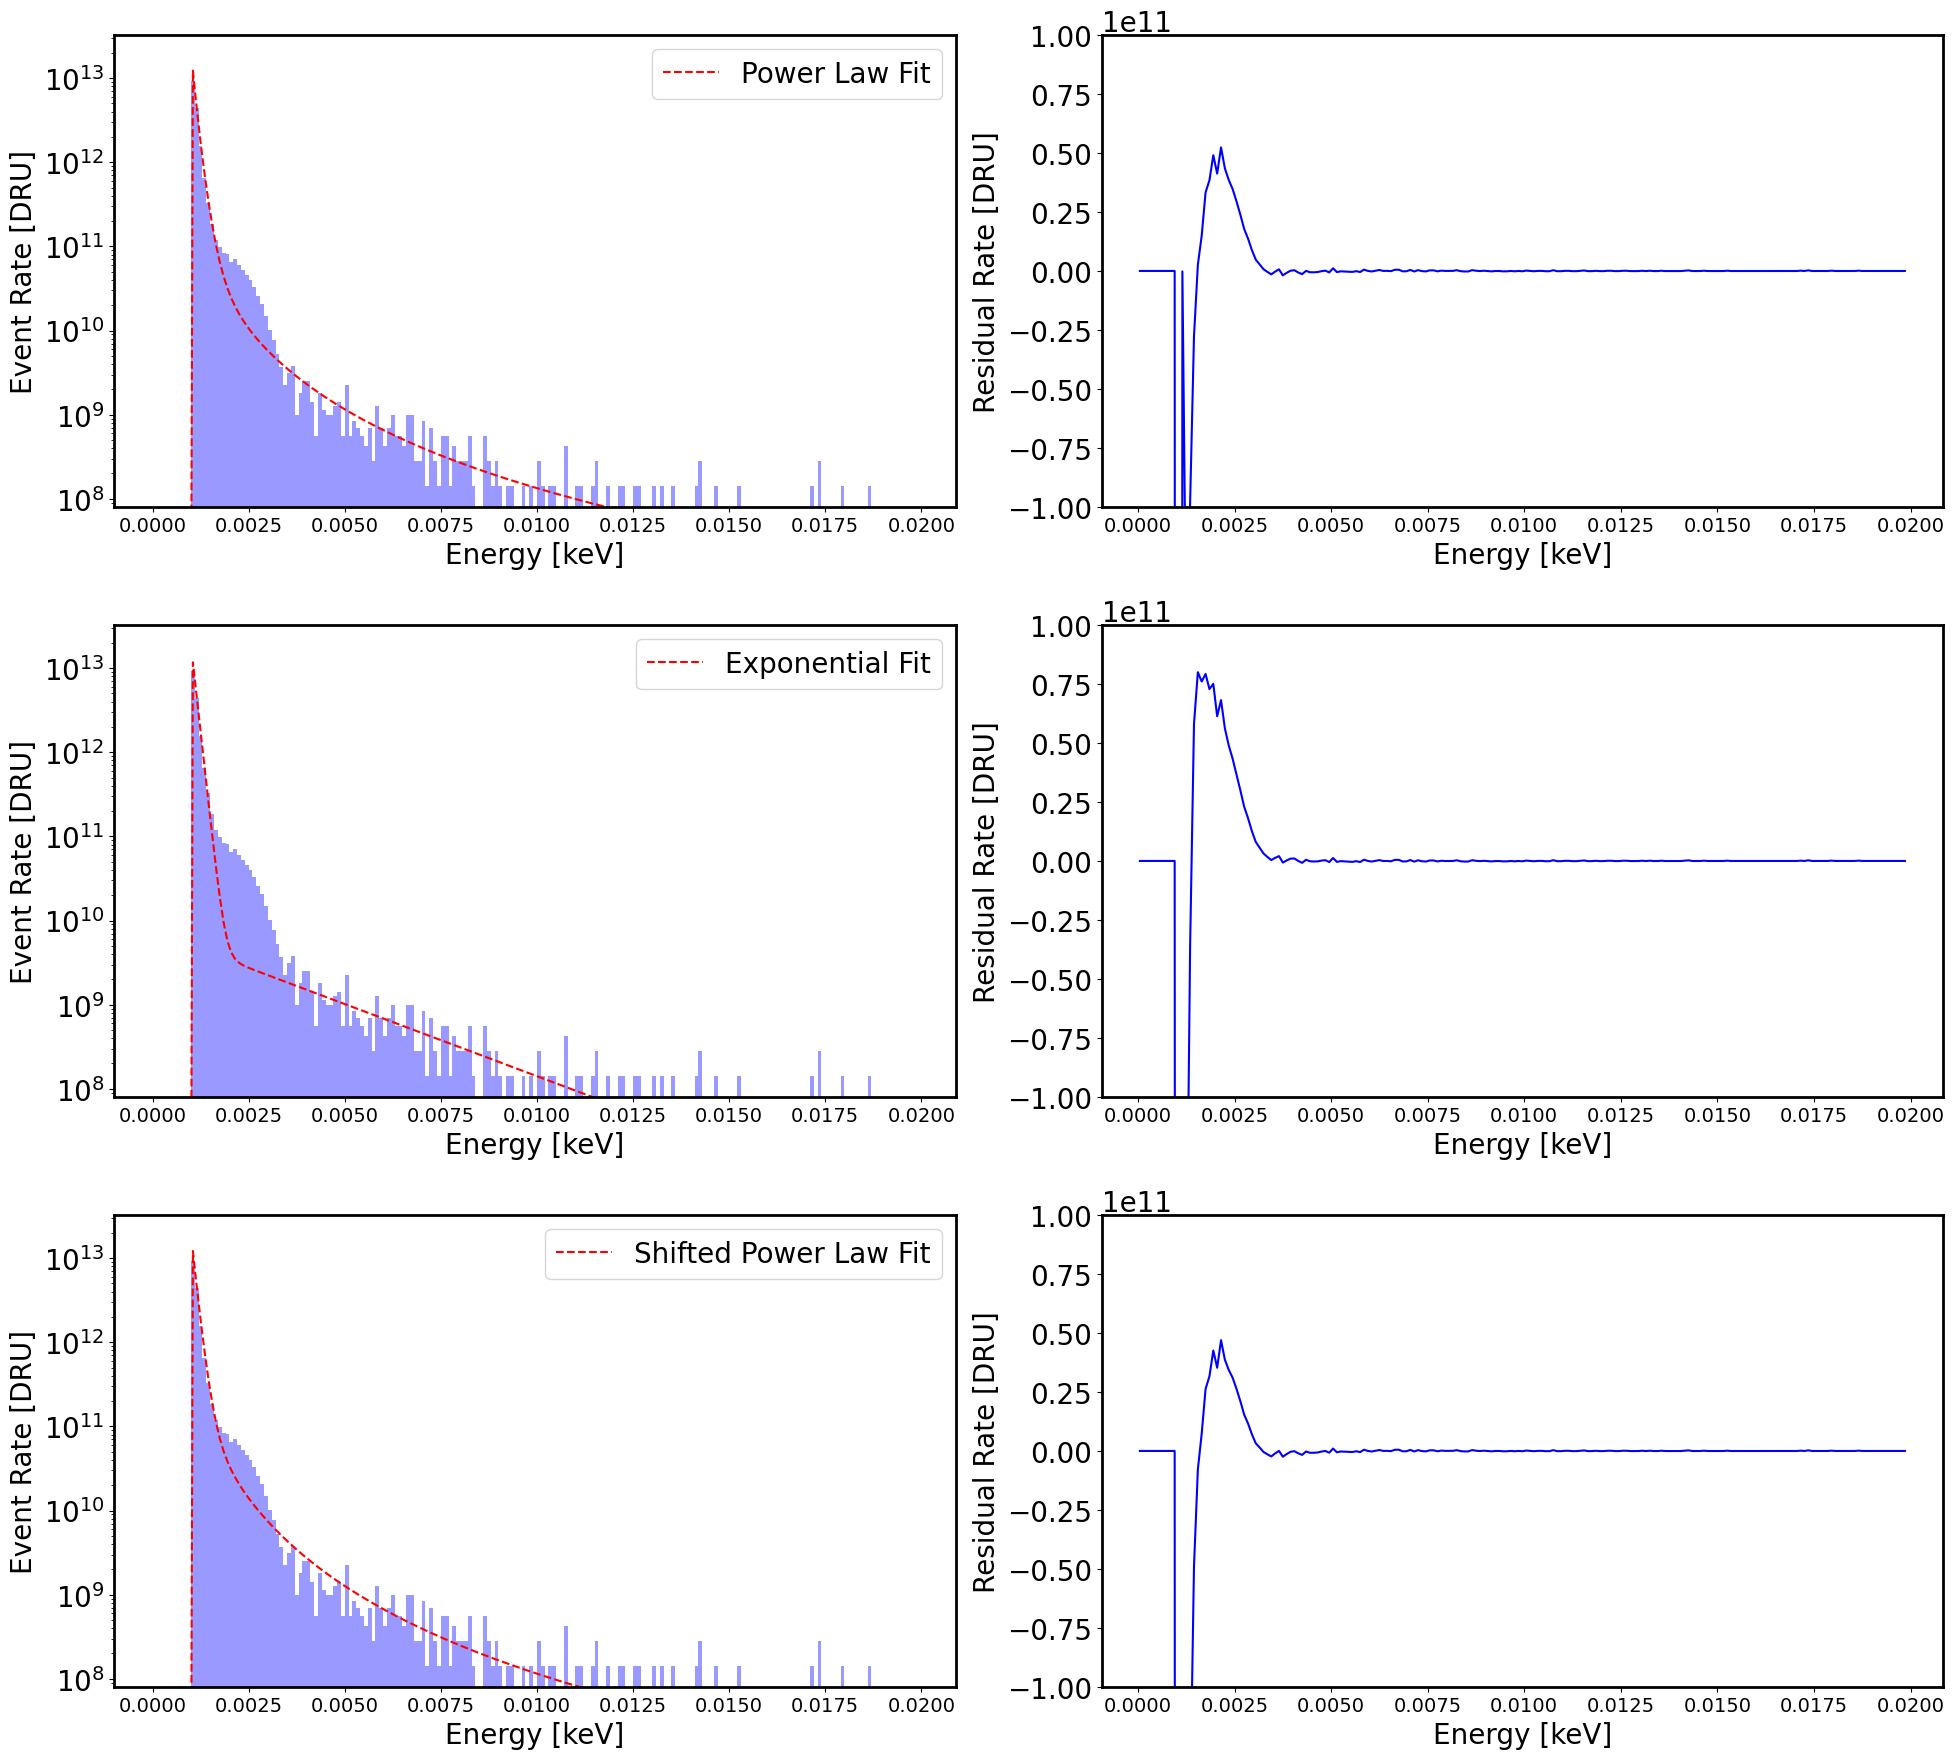

In [21]:
####### Plotting #######

fig, ax = plt.subplots(3, 2, figsize=(20, 18))

for i in range(3):

    # Calculate histogram
    hist, bin_edges = np.histogram(energies_keV, bins_keV_full, weights=event_weights_DRU)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    # Plot histogram of real data
    ax[i,0].hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='b')
    ax[i,0].set_yscale('log')
    ymin, ymax = ax[i,0].get_ylim()

    if i == 0:
        ax[i,0].plot(bin_centers, power_law(bin_centers, A_fit_power, alpha_fit_power, Eth_power, inv_width_power) + power_law(bin_centers, A_fit_power_me, alpha_fit_power_me, Eth_power, inv_width_power), 'r--', label='Power Law Fit')
        ax[i,1].plot(bin_centers, hist - power_law(bin_centers, A_fit_power, alpha_fit_power, Eth_power, inv_width_power) - power_law(bin_centers, A_fit_power_me, alpha_fit_power_me, Eth_power, inv_width_power), 'b-')
    elif i == 1:
        ax[i,0].plot(bin_centers, exponential(bin_centers, A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp) + exponential(bin_centers, A_fit_exp_me, inv_E0_exp_me, Eth_exp, inv_width_exp), 'r--', label='Exponential Fit')
        ax[i,1].plot(bin_centers, hist - exponential(bin_centers, A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp) - exponential(bin_centers, A_fit_exp_me, inv_E0_exp_me, Eth_exp, inv_width_exp), 'b-')
    elif i == 2:
        ax[i,0].plot(bin_centers, shifted_power_law(bin_centers, N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted) + shifted_power_law(bin_centers, N_fit_shifted_me, a_fit_shifted_me, b_fit_shifted_me, Eth_shifted, inv_width_shifted), 'r--', label='Shifted Power Law Fit')
        ax[i,1].plot(bin_centers, hist - shifted_power_law(bin_centers, N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted) - shifted_power_law(bin_centers, N_fit_shifted_me, a_fit_shifted_me, b_fit_shifted_me, Eth_shifted, inv_width_shifted), 'b-')

    ax[i,0].set_ylim([ymin, ymax * 2])
    ax[i,0].set_xlabel('Energy [keV]')
    ax[i,0].set_ylabel('Event Rate [DRU]')
    ax[i,0].tick_params(axis='x', which='major', labelsize=14)
    ax[i,0].legend(loc='best')
    ax[i,1].set_xlabel('Energy [keV]')
    ax[i,1].set_ylabel('Residual Rate [DRU]')
    ax[i,1].set_ylim([-1e11, 1e11])
    ax[i,1].tick_params(axis='x', which='major', labelsize=14)

fig.tight_layout()
fig.show()

####### Plotting #######


# Singles

In [8]:
energies_eV = np.load('spectra/r57_1226_1mm_single_left.npy') / 0.32 # PCE estimate
energies_keV = energies_eV / 1000

print(f'{len(energies_eV)} events')

event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

128737 events


Power law parameters [in eV]: A = 7.706e+11 DRU, exponent = -6.1157
Threshold = 6.541e-01 eV, width = 7.22604e-04 eV
Power law parameters [in keV]: A = 3.465e-07 DRU, exponent = -6.1157
Threshold = 6.541e-04 keV, width = 7.22604e-07 keV

Exponential parameters [in eV]: A = 5.729e+14 DRU, E0 = 1.5493e-01 eV
Threshold = 6.526e-01 eV, width = 8.10070e-04 eV
Exponential parameters [in keV]: A = 5.729e+14 DRU, E0 = 1.5493e-04 keV
Threshold = 6.526e-04 keV, width = 8.1007e-07 keV

Shifted Power law parameters [in eV]: N = 1.510e+15 DRU, a = 0.4924 eV, b = 9.3353
Threshold = 6.528e-01 eV, width = 1.99998e-03 eV
Shifted Power law parameters [in keV]: N = 1.510e+12 DRU, a = 0.0005 keV, b = 9.3353
Threshold = 6.528e-04 eV, width = 1.99998e-06 eV



/tmp/ipykernel_1397302/637040673.py:20: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-x * alpha) / (1 + np.exp(-(x - x0)*k))
/tmp/ipykernel_1397302/637040673.py:40: RuntimeWarning: divide by zero encountered in log
  nll = np.sum(y - counts * np.log(y))
/tmp/ipykernel_1397302/637040673.py:40: RuntimeWarning: invalid value encountered in multiply
  nll = np.sum(y - counts * np.log(y))


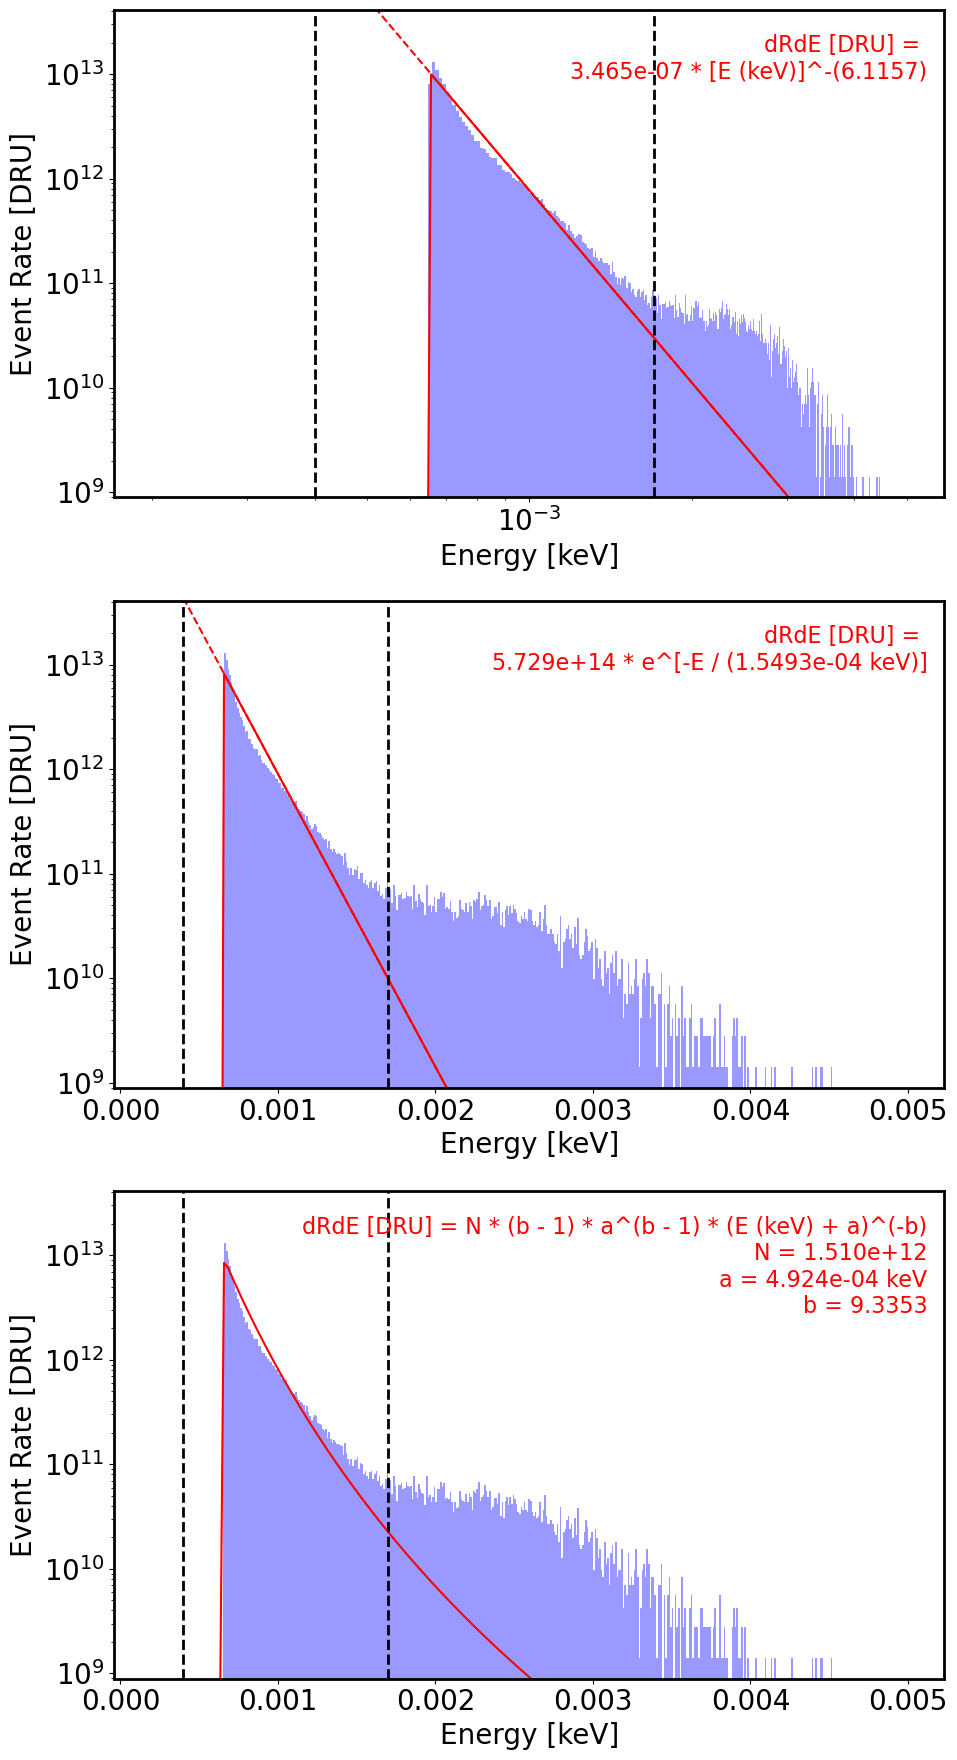

In [9]:
bins_eV_full = np.arange(0.2, 5, 0.01)
bins_keV_full = bins_eV_full / 1000
# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

# Do the fit in eV, then convert to keV (it converges better this way)
fit_low, fit_high = 0.4, 1.7
bins_eV_fit = bins_eV_full[(bins_eV_full > fit_low) * (bins_eV_full < fit_high)]

dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_fit, weights=event_weights_DRU)
E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
E_keV_arr = E_eV_arr / 1000

# Minimize the negative log likelihood for a power-law background
# Divide the rate by 1e11 first to help the fit converge
fit_scale = 1e12
result = minimize(negative_log_likelihood_power, [1, 10, 1, 10], args=(E_eV_arr, dRdE_DRU_arr/fit_scale), method='L-BFGS-B', bounds=[(1e-10, None), (1e-10, None), (0.5, 1.5), (1e-10, None)])
A_fit_power, alpha_fit_power, Eth_power, inv_width_power = result.x
A_fit_power *= fit_scale
print(f"Power law parameters [in eV]: A = {A_fit_power:.3e} DRU, exponent = -{alpha_fit_power:.4f}")
print(f'Threshold = {Eth_power:.3e} eV, width = {1 / inv_width_power:.5e} eV')
A_fit_power *= 1000**(-1 * alpha_fit_power)
Eth_power *= (1/1000)
inv_width_power *= 1000
print(f"Power law parameters [in keV]: A = {A_fit_power:.3e} DRU, exponent = -{alpha_fit_power:.4f}")
print(f'Threshold = {Eth_power:.3e} keV, width = {1 / inv_width_power:.5e} keV')
print('')

# Minimize the negative log likelihood for a exponential background
fit_scale = 1e15
result = minimize(negative_log_likelihood_exp, [1, 0.1, 1, 10], args=(E_eV_arr, dRdE_DRU_arr/fit_scale), method='L-BFGS-B', bounds=[(1e-10, None), (1e-10, None), (0.5, 1.5), (1e-10, None)])
A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp = result.x
A_fit_exp *= fit_scale
print(f"Exponential parameters [in eV]: A = {A_fit_exp:.3e} DRU, E0 = {1 / inv_E0_exp:.4e} eV")
print(f'Threshold = {Eth_exp:.3e} eV, width = {1 / inv_width_exp:.5e} eV')
inv_E0_exp *= 1000
Eth_exp *= (1/1000)
inv_width_exp *= 1000
print(f"Exponential parameters [in keV]: A = {A_fit_exp:.3e} DRU, E0 = {1 / inv_E0_exp:.4e} keV")
print(f'Threshold = {Eth_exp:.3e} keV, width = {1 / inv_width_exp:.4e} keV')
print('')

# Minimize the negative log likelihood for a shifted power-law background
fit_scale = 3e14
result = minimize(negative_log_likelihood_shifted_power, [1, 0.4, 7., 0.65, 500],
                  args=(E_eV_arr, dRdE_DRU_arr/fit_scale),
                  method='L-BFGS-B', bounds=[(1e-10, None), (1e-10, None), (1, None), (0.5, 1.), (1e-10, None)])
N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted = result.x #np.append(result.x, np.array([.65, 500]))
#N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted = [1, 0.4, 7., 0.65, 500]
N_fit_shifted *= fit_scale
print(f"Shifted Power law parameters [in eV]: N = {N_fit_shifted:.3e} DRU, a = {a_fit_shifted:.4f} eV, b = {b_fit_shifted:.4f}")
print(f'Threshold = {Eth_shifted:.3e} eV, width = {1 / inv_width_shifted:.5e} eV')
N_fit_shifted /= 1000
a_fit_shifted /= 1000
Eth_shifted *= (1/1000)
inv_width_shifted *= 1000
print(f"Shifted Power law parameters [in keV]: N = {N_fit_shifted:.3e} DRU, a = {a_fit_shifted:.4f} keV, b = {b_fit_shifted:.4f}")
print(f'Threshold = {Eth_shifted:.3e} eV, width = {1 / inv_width_shifted:.5e} eV')
print('')

####### Plotting #######

fig, ax = plt.subplots(3, 1, figsize=(10, 18))

for i in range(3):
    ax[i].hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='b')
    ax[i].set_yscale('log')
    ymin, ymax = ax[i].get_ylim()

    keV_arr_fit = np.linspace(min(bins_keV_full), max(bins_keV_full), 200)
    
    if i == 0:
        ax[i].set_xscale('log')
        ax[i].plot(keV_arr_fit, power_law(keV_arr_fit, A_fit_power, alpha_fit_power, Eth_power, inv_width_power), 'r-')
        ax[i].plot(keV_arr_fit, power_law_basic(keV_arr_fit, A_fit_power, alpha_fit_power), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_power:.3e} * [E (keV)]^-({alpha_fit_power:.4f})', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 1:
        ax[i].plot(keV_arr_fit, exponential(keV_arr_fit, A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp), 'r-')
        ax[i].plot(keV_arr_fit, exponential_basic(keV_arr_fit, A_fit_exp, inv_E0_exp), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_exp:.3e} * e^[-E / ({1/inv_E0_exp:.4e} keV)]', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 2:
        #ax[i].set_xscale('log')
        #ax[i].plot(keV_arr_fit, shifted_power_law(keV_arr_fit, 3e11, 4e-4, 7, 0.65e-3, 1e6), 'r-')
        ax[i].plot(keV_arr_fit, shifted_power_law(keV_arr_fit, N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted), 'r-')
        #ax[i].plot(keV_arr_fit, shifted_power_law_basic(keV_arr_fit, N_fit_shifted, a_fit_shifted, b_fit_shifted), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = N * (b - 1) * a^(b - 1) * (E (keV) + a)^(-b)\nN = {N_fit_shifted:.3e}\na = {a_fit_shifted:.3e} keV\nb = {b_fit_shifted:.4f}',
                   ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)

    #ax[i].text(3, 5e11, f'Fit Region', ha='right', va='top', fontsize=24, color='k')

    ax[i].set_xlabel('Energy [keV]')
    ax[i].set_ylabel('Event Rate [DRU]')

    ax[i].plot([fit_low/1e3, fit_low/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].plot([fit_high/1e3, fit_high/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].set_ylim([ymin, ymax*2])

fig.tight_layout()
fig.show()

####### Plotting #######


### Medium energy fit

Power law parameters [in eV]: A = 6.664e+10 DRU, exponent = -2.7210
Power law parameters [in keV]: A = 4.579e+02 DRU, exponent = -2.7210

Shifted Power law parameters [in eV]: N = 1.514e+11 DRU, a = 0.6419 eV, b = 2.9057
Shifted Power law parameters [in keV]: N = 1.514e+08 DRU, a = 0.0006 keV, b = 2.9057

Exponential parameters [in eV]: A = 2.205e+09 DRU, E0 = 3.8082e+00 eV
Exponential parameters [in keV]: A = 2.205e+09 DRU, E0 = 3.8082e-03 keV


/tmp/ipykernel_1087900/637040673.py:3: RuntimeWarning: divide by zero encountered in power
  return A * x**(-alpha)


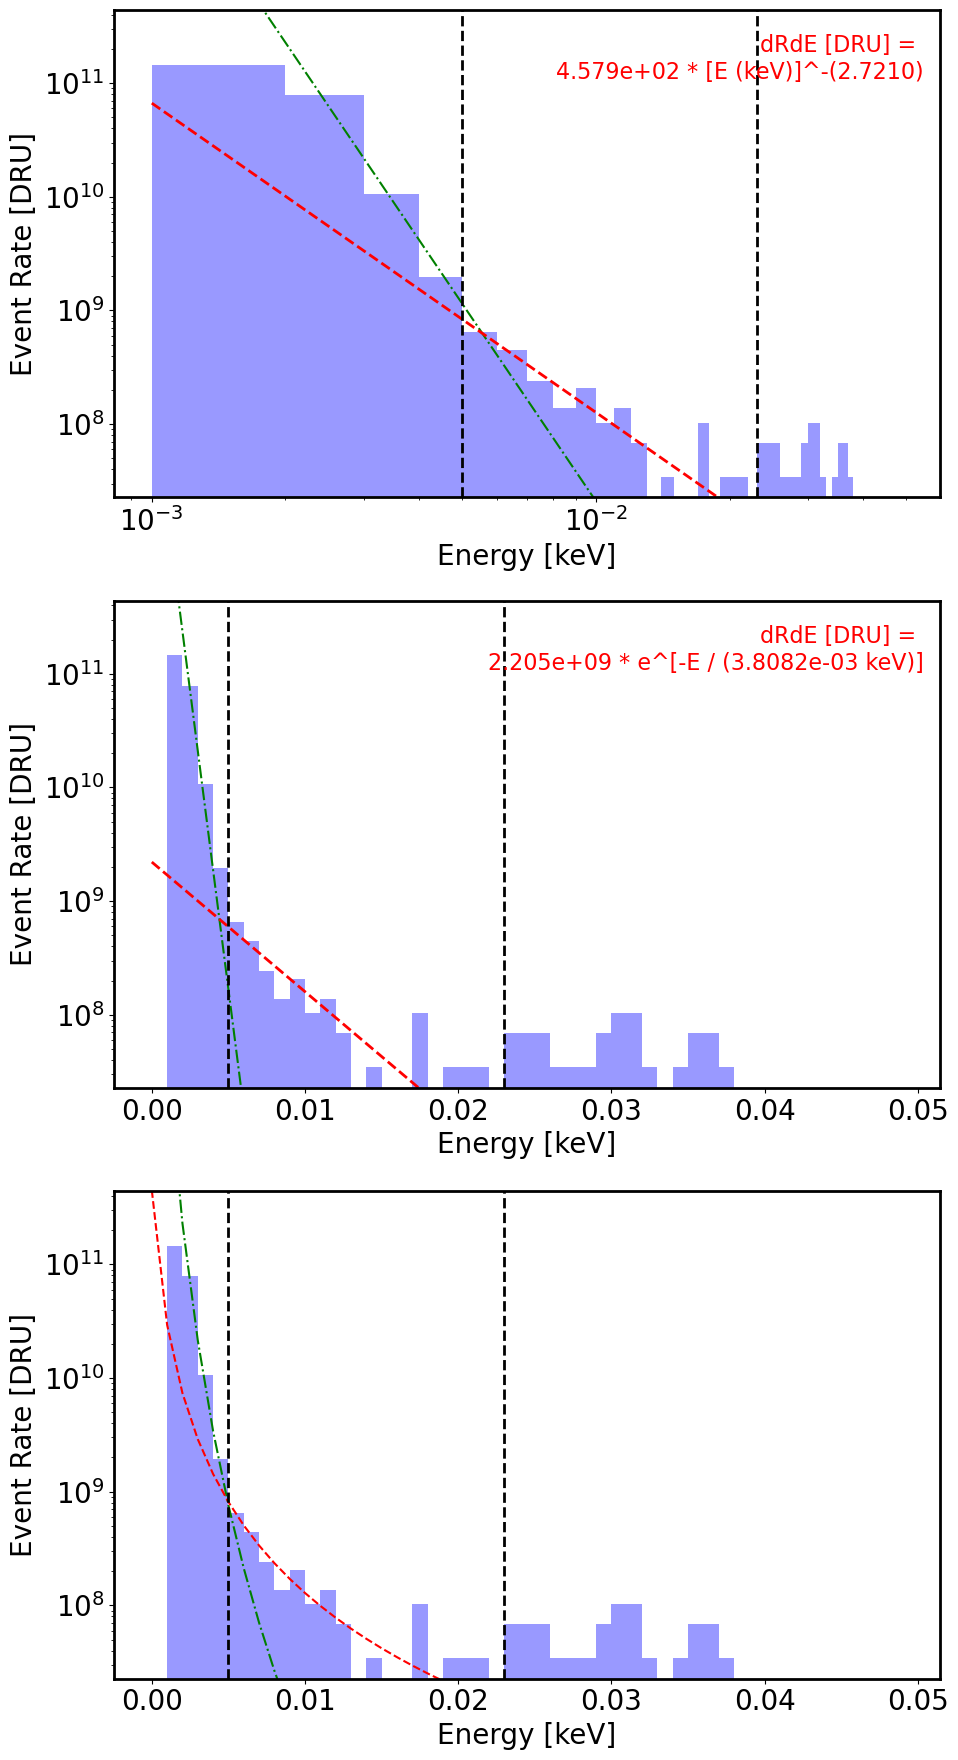

In [6]:
bins_eV_full =  np.arange(0, 50, 1)
bins_keV_full = bins_eV_full / 1000
# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

# Do the fit in eV, then convert to keV (it converges better this way)
fit_low, fit_high = 5, 23
bins_eV_fit = bins_eV_full[(bins_eV_full >= fit_low) * (bins_eV_full <= fit_high)]

dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_fit, weights=event_weights_DRU)
E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])

# Minimize the negative log likelihood for a exponential background
# Divide the rate by 1e8 first to help the fit converge
fit_scale = 1e8
result = minimize(negative_log_likelihood_power_basic, [1, 1], args=(E_eV_arr, dRdE_DRU_arr/fit_scale), method='L-BFGS-B', bounds=[(1e-10, None), (1e-10, None)])
A_fit_power_me, alpha_fit_power_me = result.x
A_fit_power_me *= fit_scale
print(f"Power law parameters [in eV]: A = {A_fit_power_me:.3e} DRU, exponent = -{alpha_fit_power_me:.4f}")
A_fit_power_me *= 1000**(-1 * alpha_fit_power_me)
print(f"Power law parameters [in keV]: A = {A_fit_power_me:.3e} DRU, exponent = -{alpha_fit_power_me:.4f}")
print('')

# Minimize the negative log likelihood for a shifted power-law background
fit_scale = 2e11
result = minimize(negative_log_likelihood_shifted_power_basic, [0.8, 0.7, 3.], args=(E_eV_arr, dRdE_DRU_arr/fit_scale), method='L-BFGS-B', bounds=[(1e-10, None), (1e-10, None), (1, None)])
N_fit_shifted_me, a_fit_shifted_me, b_fit_shifted_me  = result.x
N_fit_shifted_me *= fit_scale
print(f"Shifted Power law parameters [in eV]: N = {N_fit_shifted_me:.3e} DRU, a = {a_fit_shifted_me:.4f} eV, b = {b_fit_shifted_me:.4f}")
N_fit_shifted_me /= 1000
a_fit_shifted_me /= 1000
print(f"Shifted Power law parameters [in keV]: N = {N_fit_shifted_me:.3e} DRU, a = {a_fit_shifted_me:.4f} keV, b = {b_fit_shifted_me:.4f}")
print('')

# Minimize the negative log likelihood for a exponential background
fit_scale = 1e8
result = minimize(negative_log_likelihood_exp_basic, [1, 1], args=(E_eV_arr, dRdE_DRU_arr/fit_scale), method='L-BFGS-B', bounds=[(1e-10, None), (1e-10, None)])
A_fit_exp_me, inv_E0_exp_me = result.x
A_fit_exp_me *= fit_scale
print(f"Exponential parameters [in eV]: A = {A_fit_exp_me:.3e} DRU, E0 = {1 / inv_E0_exp_me:.4e} eV")
inv_E0_exp_me *= 1000
print(f"Exponential parameters [in keV]: A = {A_fit_exp_me:.3e} DRU, E0 = {1 / inv_E0_exp_me:.4e} keV")

####### Plotting #######

fig, ax = plt.subplots(3, 1, figsize=(10, 18))

for i in range(3):
    ax[i].hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='b')
    ax[i].set_yscale('log')
    ymin, ymax = ax[i].get_ylim()

    if i == 0:
        ax[i].set_xscale('log')
        ax[i].plot(bins_keV_full, power_law_basic(bins_keV_full, A_fit_power, alpha_fit_power), 'g-.')
        ax[i].plot(bins_keV_full, power_law_basic(bins_keV_full, A_fit_power_me, alpha_fit_power_me), 'r--', lw=2)
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_power_me:.3e} * [E (keV)]^-({alpha_fit_power_me:.4f})', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 1:
        ax[i].plot(bins_keV_full, exponential_basic(bins_keV_full, A_fit_exp, inv_E0_exp), 'g-.')
        ax[i].plot(bins_keV_full, exponential_basic(bins_keV_full, A_fit_exp_me, inv_E0_exp_me), 'r--', lw=2)
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_exp_me:.3e} * e^[-E / ({1/inv_E0_exp_me:.4e} keV)]', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 2:
        ax[i].plot(bins_keV_full, shifted_power_law_basic(bins_keV_full, N_fit_shifted, a_fit_shifted, b_fit_shifted), 'g-.')
        ax[i].plot(bins_keV_full, shifted_power_law_basic(bins_keV_full, N_fit_shifted_me, a_fit_shifted_me, b_fit_shifted_me), 'r--')

    #ax[i].text(3, 5e11, f'Fit Region', ha='right', va='top', fontsize=24, color='k')

    ax[i].set_xlabel('Energy [keV]')
    ax[i].set_ylabel('Event Rate [DRU]')



    ax[i].plot([fit_low/1e3, fit_low/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].plot([fit_high/1e3, fit_high/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].set_ylim([ymin, ymax*2])

fig.tight_layout()
fig.show()

# Plotting

### Plot the exponential fits alone

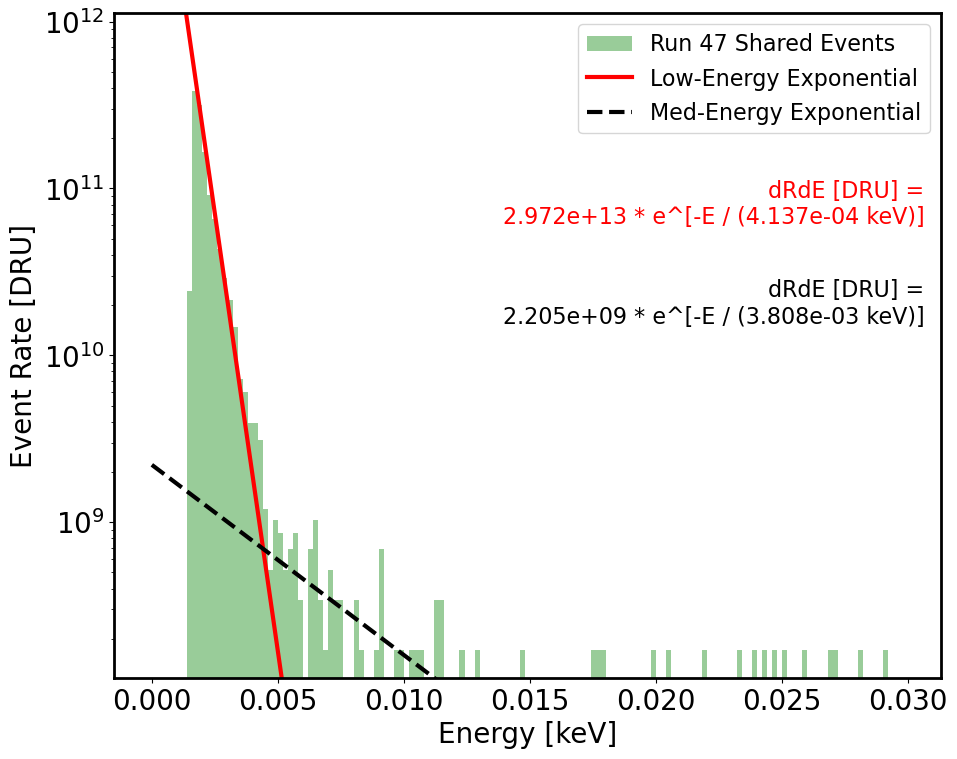

In [7]:
bins_eV_full = np.arange(0, 30, 0.2)
bins_keV_full = bins_eV_full / 1000

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='g', label='Run 47 Shared Events')
ax.set_yscale('log')
ymin, ymax = ax.get_ylim()

ax.plot(bins_keV_full, exponential_basic(bins_keV_full, A_fit_exp, inv_E0_exp), 'r-', lw=3, label='Low-Energy Exponential')
ax.text(0.98, 0.75, f'dRdE [DRU] =\n{A_fit_exp:.3e} * e^[-E / ({1/inv_E0_exp:.3e} keV)]', ha='right', va='top', fontsize=16, color='r', transform=ax.transAxes)
ax.plot(bins_keV_full, exponential_basic(bins_keV_full, A_fit_exp_me, inv_E0_exp_me), 'k--', lw=3, label='Med-Energy Exponential')
ax.text(0.98, 0.60, f'dRdE [DRU] =\n{A_fit_exp_me:.3e} * e^[-E / ({1/inv_E0_exp_me:.3e} keV)]', ha='right', va='top', fontsize=16, color='k', transform=ax.transAxes)


#ax[i].text(3, 5e11, f'Fit Region', ha='right', va='top', fontsize=24, color='k')

ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Event Rate [DRU]')

ax.set_ylim([ymin, ymax*2])
ax.legend(loc='upper right', fontsize=16)
fig.tight_layout()
fig.show()

### Plot the power fits alone

/tmp/ipykernel_1087900/637040673.py:3: RuntimeWarning: divide by zero encountered in power
  return A * x**(-alpha)


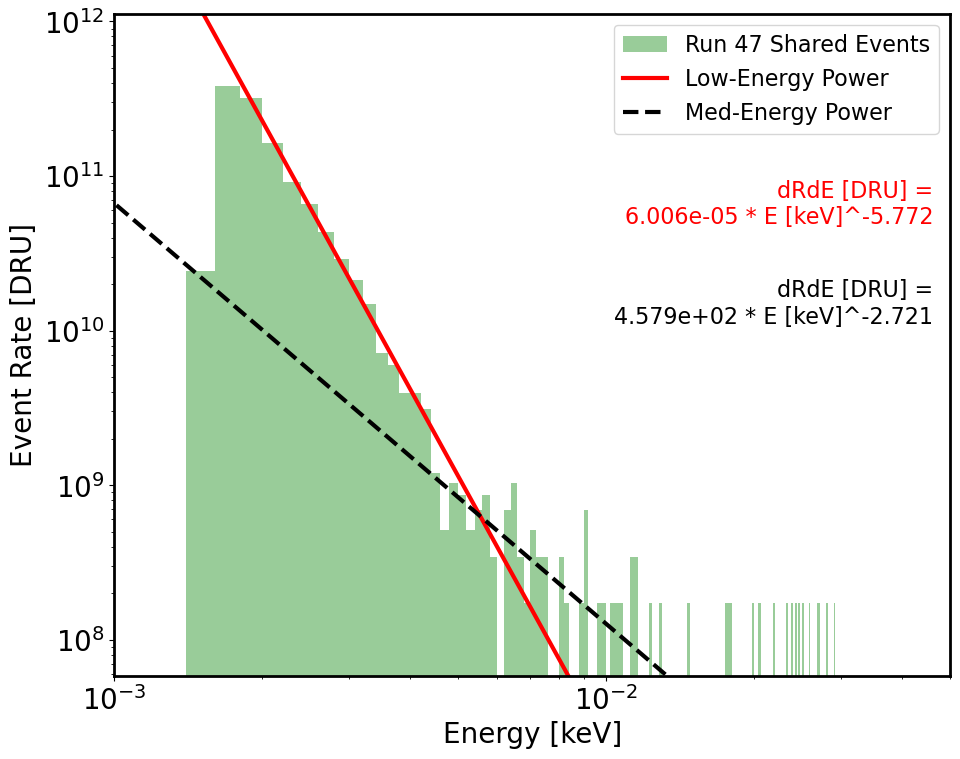

In [8]:
bins_eV_full = np.arange(0, 30, 0.2)
bins_keV_full = bins_eV_full / 1000

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='g', label='Run 47 Shared Events')
ax.set_yscale('log')
ax.set_xscale('log')
ymin, ymax = ax.get_ylim()

ax.plot(bins_keV_full, power_law_basic(bins_keV_full, A_fit_power, alpha_fit_power), 'r-', lw=3, label='Low-Energy Power')
ax.text(0.98, 0.75, f'dRdE [DRU] =\n{A_fit_power:.3e} * E [keV]^-{alpha_fit_power:.3f}', ha='right', va='top', fontsize=16, color='r', transform=ax.transAxes)
ax.plot(bins_keV_full, power_law_basic(bins_keV_full, A_fit_power_me, alpha_fit_power_me), 'k--', lw=3, label='Med-Energy Power')
ax.text(0.98, 0.60, f'dRdE [DRU] =\n{A_fit_power_me:.3e} * E [keV]^-{alpha_fit_power_me:.3f}', ha='right', va='top', fontsize=16, color='k', transform=ax.transAxes)


#ax[i].text(3, 5e11, f'Fit Region', ha='right', va='top', fontsize=24, color='k')

ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Event Rate [DRU]')

ax.set_ylim([ymin/2, ymax*2])
ax.set_xlim([1e-3, 50e-3])
ax.legend(loc='upper right', fontsize=16)
fig.tight_layout()
fig.show()

### Compare to Run 34

/tmp/ipykernel_1087900/1491716195.py:17: RuntimeWarning: divide by zero encountered in log10
  ax.plot(E_eV_arr, np.log10(dRdE_DRU_arr), 'ko', ms=8, label='Run 47 Data')
/tmp/ipykernel_1087900/637040673.py:3: RuntimeWarning: divide by zero encountered in power
  return A * x**(-alpha)


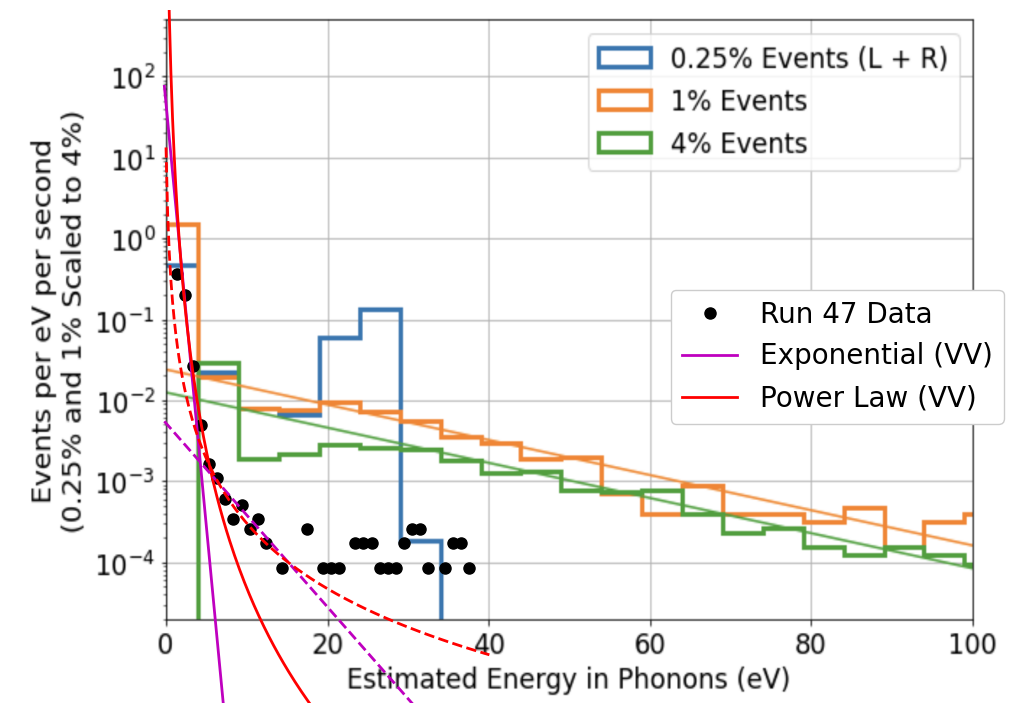

In [9]:
# Load the image
img = mpimg.imread('spectra/RKR_Run34_spectrum.png')

# Create a figure and axis
fig, ax = plt.subplots(1, 1, figsize=(13,9))

# Display the image
ax.imshow(img, extent=[-19, 105, np.log10(2e-6), np.log10(7e2)], aspect='auto')

# Rebin the data and recalculate weights
bins_eV = np.arange(0, 100, 1)
event_weights_eVs = np.full(len(energies_eV), (1/time_sec/np.diff(bins_eV)[0]))

# Plot the raw histogram onto the previous Run 34 plot
dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV, weights=event_weights_eVs)
E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
ax.plot(E_eV_arr, np.log10(dRdE_DRU_arr), 'ko', ms=8, label='Run 47 Data')

# Plot the exponential and power fits onto the same plot (converted from DRU to cts/eV/s)
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
E_eV_arr = np.linspace(0, 40, 200)
ax.plot(E_eV_arr, np.log10(exponential_basic(E_eV_arr, A_fit_exp / 1000 / 86400 * mass_kg, inv_E0_exp / 1e3)), 'm-', lw=2, label='Exponential (VV)')
ax.plot(E_eV_arr, np.log10(power_law_basic(E_eV_arr, A_fit_power * 1000**(alpha_fit_power - 1) / 86400 * mass_kg, alpha_fit_power)), 'r-', lw=2, label='Power Law (VV)')
ax.plot(E_eV_arr, np.log10(exponential_basic(E_eV_arr, A_fit_exp_me / 1000 / 86400 * mass_kg, inv_E0_exp_me / 1e3)), 'm--', lw=2)
ax.plot(E_eV_arr, np.log10(power_law_basic(E_eV_arr, A_fit_power_me * 1000**(alpha_fit_power_me - 1) / 86400 * mass_kg, alpha_fit_power_me)), 'r--', lw=2)
ax.set_xlim([xmin, xmax])
ax.set_ylim([ymin, ymax])
ax.legend(loc='center right', framealpha=1)

# Show the plot
ax.axis(False)
plt.show()


/tmp/ipykernel_1087900/637040673.py:3: RuntimeWarning: divide by zero encountered in power
  return A * x**(-alpha)


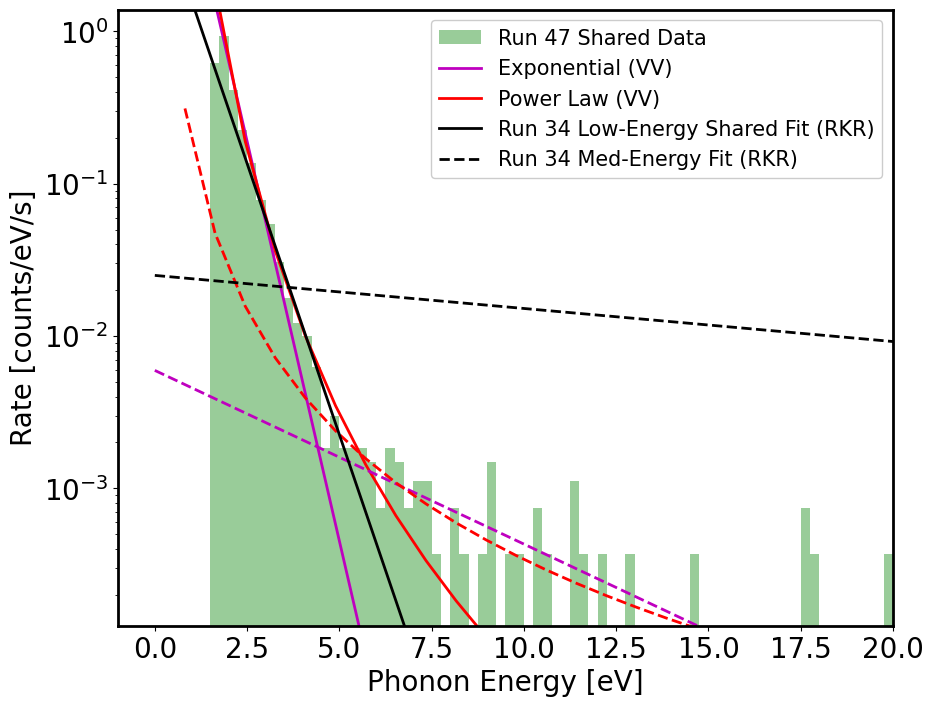

In [10]:
def get_shared_rate_phonon_eVs(energies_phonon, pce=0.164):
    energies_TES = energies_phonon * pce
    return 50 * np.exp(-energies_TES / 100e-3) * pce

# Create a figure and axis
fig, ax = plt.subplots(1, 1, figsize=(10,8))

bins_eV = np.arange(1.5, 50, 0.25)
event_weights_eVs = np.full(len(energies_eV), (1/time_sec/np.diff(bins_eV)[0]))
dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV, weights=event_weights_eVs)
E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
#ax.plot(E_eV_arr, dRdE_DRU_arr, 'ko', ms=8, label='Run 47 Data')
ax.hist(energies_eV, bins_eV, weights=event_weights_eVs, label='Run 47 Shared Data', alpha=0.4, color='g')
ax.set_yscale('log')

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
E_eV_arr = np.linspace(0, 40)
ax.plot(E_eV_arr, exponential_basic(E_eV_arr, A_fit_exp / 1000 / 86400 * mass_kg, inv_E0_exp / 1e3), 'm-', lw=2, label='Exponential (VV)')
ax.plot(E_eV_arr, power_law_basic(E_eV_arr, A_fit_power * 1000**(alpha_fit_power - 1) / 86400 * mass_kg, alpha_fit_power), 'r-', lw=2, label='Power Law (VV)')
ax.plot(E_eV_arr, exponential_basic(E_eV_arr, A_fit_exp_me / 1000 / 86400 * mass_kg, inv_E0_exp_me / 1e3), 'm--', lw=2)
ax.plot(E_eV_arr, power_law_basic(E_eV_arr, A_fit_power_me * 1000**(alpha_fit_power_me - 1) / 86400 * mass_kg, alpha_fit_power_me), 'r--', lw=2)
ax.plot(E_eV_arr, get_shared_rate_phonon_eVs(E_eV_arr), 'k-', lw=2, label='Run 34 Low-Energy Shared Fit (RKR)')
ax.plot(E_eV_arr, exponential_basic(E_eV_arr, 0.025, 1/20), 'k--', lw=2, label='Run 34 Med-Energy Fit (RKR)')
#ax.set_xscale('log')
ax.set_xlim([1, 50])
ax.set_ylim([ymin/2, ymax])
ax.set_xlabel('Phonon Energy [eV]')
ax.set_ylabel('Rate [counts/eV/s]')
ax.legend(loc='upper right', framealpha=1, fontsize=15)
ax.set_xlim([-1, 20])
fig.show()

# Consider 1x1 cm2 sapphire chip, running for 1 second

For E_threshold = 0.15 eV, events in 1 second = 23.69
For E_threshold = 0.25 eV, events in 1 second = 18.61
For E_threshold = 0.40 eV, events in 1 second = 12.95
For E_threshold = 0.50 eV, events in 1 second = 10.18
For E_threshold = 1.00 eV, events in 1 second = 3.05
For E_threshold = 1.85 eV, events in 1 second = 0.40
For E_threshold = 2.50 eV, events in 1 second = 0.09
For E_threshold = 5.00 eV, events in 1 second = 0.01


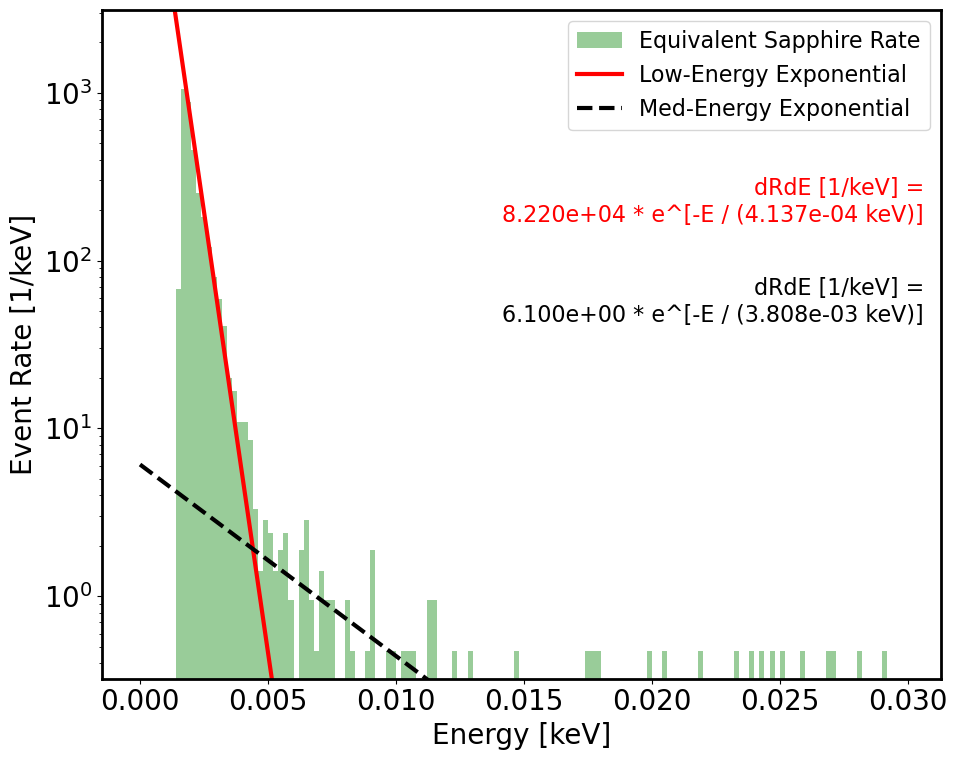

In [11]:
bins_eV_full = np.arange(0, 30, 0.2)
bins_keV_full = bins_eV_full / 1000

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))
mass_kg_sapphire = (1 * 1 * 0.1) * 2.39 * 1e-3
t_days_sapphire = 1 / 86400.
event_weights_DRU *= (mass_kg_sapphire * t_days_sapphire)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='g', label='Equivalent Sapphire Rate')
ax.set_yscale('log')
ymin, ymax = ax.get_ylim()

ax.plot(bins_keV_full, exponential_basic(bins_keV_full, A_fit_exp, inv_E0_exp) * (mass_kg_sapphire * t_days_sapphire), 'r-', lw=3, label='Low-Energy Exponential')
ax.text(0.98, 0.75, f'dRdE [1/keV] =\n{A_fit_exp * (mass_kg_sapphire * t_days_sapphire):.3e} * e^[-E / ({1/inv_E0_exp:.3e} keV)]', ha='right', va='top', fontsize=16, color='r', transform=ax.transAxes)
ax.plot(bins_keV_full, exponential_basic(bins_keV_full, A_fit_exp_me, inv_E0_exp_me) * (mass_kg_sapphire * t_days_sapphire), 'k--', lw=3, label='Med-Energy Exponential')
ax.text(0.98, 0.60, f'dRdE [1/keV] =\n{A_fit_exp_me * (mass_kg_sapphire * t_days_sapphire):.3e} * e^[-E / ({1/inv_E0_exp_me:.3e} keV)]', ha='right', va='top', fontsize=16, color='k', transform=ax.transAxes)

ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Event Rate [1/keV]')

ax.set_ylim([ymin, ymax*2])
ax.legend(loc='upper right', fontsize=16)
fig.tight_layout()
fig.show()

for E_resolution_meV in [30, 50, 80, 100, 200, 370, 500, 1000]:
    
    E_threshold_keV = E_resolution_meV * 1e-6 * 5
    
    events_in_1_second =  A_fit_exp_me * (mass_kg_sapphire * t_days_sapphire) / inv_E0_exp_me * np.exp(-E_threshold_keV * inv_E0_exp_me) + \
        A_fit_exp * (mass_kg_sapphire * t_days_sapphire) / inv_E0_exp * np.exp(-E_threshold_keV * inv_E0_exp)
        
    print(f'For E_threshold = {E_threshold_keV * 1e3:.2f} eV, events in 1 second = {events_in_1_second:.2f}')

/tmp/ipykernel_1087900/637040673.py:3: RuntimeWarning: divide by zero encountered in power
  return A * x**(-alpha)


For E_threshold = 0.15 eV, events in 1 second = 61422.48
For E_threshold = 0.25 eV, events in 1 second = 5367.94
For E_threshold = 0.40 eV, events in 1 second = 570.31
For E_threshold = 0.50 eV, events in 1 second = 196.82
For E_threshold = 1.00 eV, events in 1 second = 7.30
For E_threshold = 1.85 eV, events in 1 second = 0.42
For E_threshold = 2.50 eV, events in 1 second = 0.11
For E_threshold = 5.00 eV, events in 1 second = 0.01


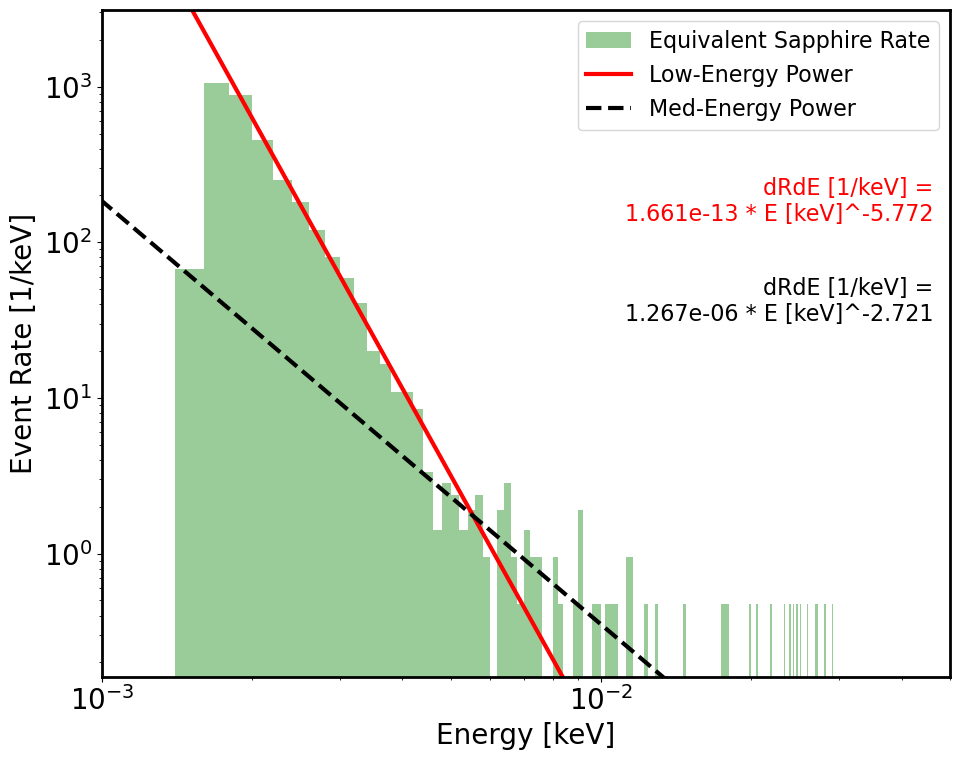

In [12]:
bins_eV_full = np.arange(0, 30, 0.2)
bins_keV_full = bins_eV_full / 1000

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))
event_weights_DRU *= (mass_kg_sapphire * t_days_sapphire)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='g', label='Equivalent Sapphire Rate')
ax.set_yscale('log')
ax.set_xscale('log')
ymin, ymax = ax.get_ylim()

ax.plot(bins_keV_full, power_law_basic(bins_keV_full, A_fit_power, alpha_fit_power) * (mass_kg_sapphire * t_days_sapphire), 'r-', lw=3, label='Low-Energy Power')
ax.text(0.98, 0.75, f'dRdE [1/keV] =\n{A_fit_power * (mass_kg_sapphire * t_days_sapphire):.3e} * E [keV]^-{alpha_fit_power:.3f}', ha='right', va='top', fontsize=16, color='r', transform=ax.transAxes)
ax.plot(bins_keV_full, power_law_basic(bins_keV_full, A_fit_power_me, alpha_fit_power_me) * (mass_kg_sapphire * t_days_sapphire), 'k--', lw=3, label='Med-Energy Power')
ax.text(0.98, 0.60, f'dRdE [1/keV] =\n{A_fit_power_me * (mass_kg_sapphire * t_days_sapphire):.3e} * E [keV]^-{alpha_fit_power_me:.3f}', ha='right', va='top', fontsize=16, color='k', transform=ax.transAxes)

ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Event Rate [1/keV]')

ax.set_ylim([ymin/2, ymax*2])
ax.set_xlim([1e-3, 50e-3])
ax.legend(loc='upper right', fontsize=16)
fig.tight_layout()
fig.show()

for E_resolution_meV in [30, 50, 80, 100, 200, 370, 500, 1000]:
    
    E_threshold_keV = E_resolution_meV * 1e-6 * 5
    
    events_in_1_second =  A_fit_power_me * (mass_kg_sapphire * t_days_sapphire) / (alpha_fit_power_me - 1) * E_threshold_keV**(1 - alpha_fit_power_me) + \
        A_fit_power * (mass_kg_sapphire * t_days_sapphire) / (alpha_fit_power - 1) * E_threshold_keV**(1 - alpha_fit_power)
                
    print(f'For E_threshold = {E_threshold_keV * 1e3:.2f} eV, events in 1 second = {events_in_1_second:.2f}')